In [1]:
import pandas as pd
from typing import Mapping, Iterable, Optional, Dict, List
from pathlib import Path
from datetime import datetime
import streamlit as st
import matplotlib.pyplot as plt
import numpy as np

# Traiter les données

## Importer

In [2]:
# transforme le csv des DE en dictionnaire
df=pd.read_csv("descripteurs.csv", encoding="utf-8")
descripteurs_dict = df.set_index("clef")[["nom", "description"]].to_dict(orient="index")

In [3]:
#importe les csv de contrôles et d'opérateurs
controles=pd.read_csv("controles.csv", encoding="utf-8").fillna(0)
operateurs=pd.read_csv("operateurs.csv", encoding="utf-8").fillna(0)
# pf=pd.read_csv("procedures.csv", encoding="utf-8")
# procedures_dict = pf.set_index("clef")[["nom", "description", "deroulement"]].to_dict(orient="index")

In [4]:
# fonction pour charger la liste des procédures comme un dictionnaire
def load_procedures_dict(csv_path: str, list_sep: str = "|") -> dict[str, dict]:
    df = pd.read_csv(csv_path, sep=",", encoding="utf-8")
    df.columns = [c.strip() for c in df.columns]
    s = df["deroulement"].fillna("").astype(str)
    df["deroulement"] = s.apply(lambda x: [t.strip() for t in x.split(list_sep) if t.strip()])
    return df.set_index("clef")[["nom", "description", "deroulement"]].to_dict(orient="index")


In [5]:
# charge le fichier procedures.csv
dict_procedures=load_procedures_dict("procedures.csv")

In [6]:
# Importe les profils élèves
eleves=pd.read_csv("eleves.csv", encoding="utf-8").fillna(0)

In [7]:
print(eleves.columns.tolist())

['clef', 'nom', 'commentaire', 'de_reco_angle_droit', 'de_planifier', 'de_position_objet', 'de_deplacer_pointeur', 'de_clic', 'de_double_clic']


## exporter

In [8]:
# fonction pour réexporter le dictionnaire de procédures en un csv horodaté
def save_procedures(dict_procedures, list_sep="|"):
    """
    Sauvegarde dict_procedures dans un fichier CSV
    nommé procedures_<horodatage>.csv.
    """
    rows = []
    for clef, data in dict_procedures.items():
        rows.append({
            "clef": clef,
            "nom": data["nom"],
            "description": data["description"],
            "deroulement": list_sep.join(data["deroulement"])
        })
    df = pd.DataFrame(rows)
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    filename = f"procedures_{ts}.csv"
    df.to_csv(filename, index=False, encoding="utf-8")
    return filename


In [9]:
#appel de la fonction sur le dictionnaire
procedures=save_procedures(dict_procedures)

In [10]:
dict_procedures

{'proc_visu': {'nom': 'Vérification visuelle',
  'description': nan,
  'deroulement': ['cont_perp_visuel']},
 'proc_equerre': {'nom': 'Soutien équerre',
  'description': 'Vérification soutenue par l’équerre',
  'deroulement': ['cont_perp_visuel',
   'cont_perp_equerre',
   'cont_perp_visuel']},
 'proc_test1': {'nom': '1',
  'description': '23',
  'deroulement': ['op_perp_sgt',
   'op_cer_comp',
   'op_nbre',
   'op_perp_equer',
   'cont_perp_codage',
   'cont_perp_equerre',
   'op_seg_ demi_dte']},
 'proc test 3': {'nom': '456',
  'description': '56',
  'deroulement': ['op_perp_pt',
   'op_mes_dec',
   'op_ajust_obj',
   'cont_perp_visuel',
   'cont_perp_codage']},
 'proc_jtesk': {'nom': 'd',
  'description': 'xgdgx',
  'deroulement': ['op_ajust_obj', 'cont_perp_visuel', 'cont_perp_codage']},
 'proc_demo': {'nom': 'Demo',
  'description': 'klsdfjmwklmvbx',
  'deroulement': ['op_perp_pt',
   'op_cer_cer',
   'cont_perp_visuel',
   'cont_perp_codage',
   'cont_perp_codage',
   'op_Dlt_al

# Calcul des coûts

## Coût d'une procédure

In [11]:
def calculer_cout_procedure(proc_key: str) -> dict:
    """
    Calcule le coût d'une procédure en sommant les contributions de chaque DE.
    Retourne un dictionnaire {DE: coût total}.
    """
    if proc_key not in dict_procedures:
        raise ValueError(f"Procédure '{proc_key}' non trouvée.")
    
    deroulement = dict_procedures[proc_key].get("deroulement", [])
    
    # Colonnes DE = celles qui commencent par 'de_'
    de_cols_ops = [c for c in operateurs.columns if c.startswith("de_")]
    de_cols_sigs = [c for c in controles.columns if c.startswith("de_")]
    
    # dictionnaire pour accumuler les coûts
    couts = {de: 0 for de in set(de_cols_ops) | set(de_cols_sigs)}
    
    for code in deroulement:
        if code in operateurs["clef"].values:
            row = operateurs.loc[operateurs["clef"] == code].iloc[0]
            for de in de_cols_ops:
                couts[de] += int(row.get(de, 0) or 0)
        elif code in controles["clef"].values:
            row = controles.loc[controles["clef"] == code].iloc[0]
            for de in de_cols_sigs:
                couts[de] += int(row.get(de, 0) or 0)
        else:
            print(f"⚠️ Attention : '{code}' non trouvé dans opérateurs ni contrôles")
    
    return couts


In [12]:
cout_perp=calculer_cout_procedure("proc_test1")
print(cout_perp)

{'de_position_objet': 5, 'de_clic': 4, 'de_deplacer_pointeur': 5, 'de_planifier': 2, 'de_double_clic': 0, 'de_reco_angle_droit': 1}


## DataFrame avec tous les coûts

In [13]:
def calculer_couts_toutes_procedures() -> pd.DataFrame:
    """
    Calcule les coûts pour toutes les procédures de dict_procedures.
    Retourne un DataFrame avec une ligne par procédure et une colonne par DE.
    """
    # Colonnes DE
    de_cols_ops = [c for c in operateurs.columns if c.startswith("de_")]
    de_cols_sigs = [c for c in controles.columns if c.startswith("de_")]
    all_de_cols = sorted(set(de_cols_ops) | set(de_cols_sigs))
    
    # Résultats
    data = []
    
    for proc_key, proc_info in dict_procedures.items():
        # coût pour cette procédure
        couts = calculer_cout_procedure(proc_key)
        row = {"procedure": proc_key, "nom": proc_info.get("nom", "")}
        row.update(couts)
        data.append(row)
    
    # DataFrame
    df = pd.DataFrame(data)
    return df.set_index("procedure")

In [14]:
df_couts = calculer_couts_toutes_procedures()


In [15]:
df_couts

,nom,de_position_objet,de_clic,de_deplacer_pointeur,de_planifier,de_double_clic,de_reco_angle_droit
procedure,,,,,,,
proc_visu,Vérification visuelle,0,0,0,0,0,1
proc_equerre,Soutien équerre,2,1,2,1,0,3
proc_test1,1,5,4,5,2,0,1
proc test 3,456,3,3,3,1,0,1
proc_jtesk,d,3,3,3,1,0,1
proc_demo,Demo,6,6,6,2,0,1
real_test,Test,8,7,8,3,0,1
proc_test5,test 5,3,3,3,1,0,1


## Coût pour les élèves

### Un élève, une procédure

In [19]:
# pour un élève
def calculer_cout_procedure_pour_eleve(proc_key: str, eleve_key: str) -> dict:
    """
    Calcule le coût détaillé d'une procédure donnée pour un élève donné.
    
    proc_key : clé de la procédure (dans dict_procedures)
    eleve_key : clé de l'élève (dans df_eleves['clef'])
    
    Retourne un dictionnaire {DE: coût total}
    """
    # Vérif des entrées
    if proc_key not in dict_procedures:
        raise ValueError(f"Procédure '{proc_key}' non trouvée.")
    if eleve_key not in eleves["clef"].values:
        raise ValueError(f"Élève '{eleve_key}' non trouvé.")
    
    # Occurrences DE dans la procédure
    couts_proc = calculer_cout_procedure(proc_key)
    
    # Profil de l'élève
    row_eleve = eleves.loc[eleves["clef"] == eleve_key].iloc[0]
    
    # Multiplication par le coût de l'élève
    couts_pondérés = {}
    for de, occ in couts_proc.items():
        poids = float(row_eleve.get(de, 0) or 0)
        couts_pondérés[de] = occ * poids
    
    return couts_pondérés


In [20]:
calculer_cout_procedure_pour_eleve("proc_test1","el_visu")

{'de_deplacer_pointeur': 5.0,
 'de_double_clic': 0.0,
 'de_reco_angle_droit': 5.0,
 'de_planifier': 2.0,
 'de_position_objet': 15.0,
 'de_clic': 4.0}

### Un élève, toutes les procédures

In [23]:
# Coût pour un élève de chacune des procédures, donne un dataframe
def calculer_couts_toutes_procedures_pour_eleve(eleve_key: str) -> pd.DataFrame:
    """
    Calcule le coût détaillé de toutes les procédures pour un élève donné.
    Retourne un DataFrame avec une ligne par procédure et une colonne par DE.
    """
    if eleve_key not in eleves["clef"].values:
        raise ValueError(f"Élève '{eleve_key}' non trouvé.")
    
    data = []
    for proc_key in dict_procedures.keys():
        couts = calculer_cout_procedure_pour_eleve(proc_key, eleve_key)
        row = {"procedure": proc_key}
        row.update(couts)
        data.append(row)
    
    df = pd.DataFrame(data).set_index("procedure")
    return df


In [24]:
df_couts = calculer_couts_toutes_procedures_pour_eleve("el_visu")
print(df_couts.head())


              de_deplacer_pointeur  de_double_clic  de_reco_angle_droit  \
procedure                                                                 
proc_visu                      0.0             0.0                  5.0   
proc_equerre                   2.0             0.0                 15.0   
proc_test1                     5.0             0.0                  5.0   
proc test 3                    3.0             0.0                  5.0   
proc_jtesk                     3.0             0.0                  5.0   

              de_planifier  de_position_objet  de_clic  
procedure                                               
proc_visu              0.0                0.0      0.0  
proc_equerre           1.0                6.0      1.0  
proc_test1             2.0               15.0      4.0  
proc test 3            1.0                9.0      3.0  
proc_jtesk             1.0                9.0      3.0  


### Une procédure, tous les élèves

In [25]:
# Coût d'une procédure pour chacun des élèves, donne un dataframe
def calculer_cout_procedure_pour_tous_les_eleves(proc_key: str) -> pd.DataFrame:
    """
    Calcule le coût détaillé d'une procédure pour tous les élèves.
    Retourne un DataFrame avec une ligne par élève et une colonne par DE.
    """
    if proc_key not in dict_procedures:
        raise ValueError(f"Procédure '{proc_key}' non trouvée.")
    
    data = []
    for _, row in eleves.iterrows():
        eleve_key = row["clef"]
        couts = calculer_cout_procedure_pour_eleve(proc_key, eleve_key)
        line = {"eleve": eleve_key}
        line.update(couts)
        data.append(line)
    
    df = pd.DataFrame(data).set_index("eleve")
    return df


In [26]:
df_eleves = calculer_cout_procedure_pour_tous_les_eleves("proc_test1")
print(df_eleves.head())


           de_deplacer_pointeur  de_double_clic  de_reco_angle_droit  \
eleve                                                                  
el_visu                     5.0             0.0                  5.0   
el_clic                    10.0             0.0                  1.0   
el_planif                   5.0             0.0                  1.0   

           de_planifier  de_position_objet  de_clic  
eleve                                                
el_visu             2.0               15.0      4.0  
el_clic             2.0                5.0     12.0  
el_planif          10.0                5.0      4.0  


### Tous les élèves, toutes les procédures

In [27]:
def calculer_couts_tous_eleves_toutes_procedures() -> pd.DataFrame:
    """
    Calcule les coûts détaillés pour toutes les procédures et tous les élèves.
    Retourne un DataFrame multi-indexé (eleve, procedure) × DE.
    """
    data = []
    
    for _, row in eleves.iterrows():
        eleve_key = row["clef"]
        for proc_key in dict_procedures.keys():
            couts = calculer_cout_procedure_pour_eleve(proc_key, eleve_key)
            line = {"eleve": eleve_key, "procedure": proc_key}
            line.update(couts)
            data.append(line)
    
    df = pd.DataFrame(data)
    df = df.set_index(["eleve", "procedure"])
    return df


In [28]:
df_cube = calculer_couts_tous_eleves_toutes_procedures()
print(df_cube.head())

                      de_deplacer_pointeur  de_double_clic  \
eleve   procedure                                            
el_visu proc_visu                      0.0             0.0   
        proc_equerre                   2.0             0.0   
        proc_test1                     5.0             0.0   
        proc test 3                    3.0             0.0   
        proc_jtesk                     3.0             0.0   

                      de_reco_angle_droit  de_planifier  de_position_objet  \
eleve   procedure                                                            
el_visu proc_visu                     5.0           0.0                0.0   
        proc_equerre                 15.0           1.0                6.0   
        proc_test1                    5.0           2.0               15.0   
        proc test 3                   5.0           1.0                9.0   
        proc_jtesk                    5.0           1.0                9.0   

                  

Usage : 
```Python
df_cube.loc["eleve_j1"]              # toutes les procédures d'un élève
df_cube.xs("proc_test1", level="procedure")  # tous les élèves pour une procédure
df_cube.sum(axis=1)                  # total par (élève, procédure)
```

### Export des coûts en csv
L'export par procédure ou par élève garde les informations vectorielles, par contre le tableau croisé ne prend que le coût total

In [149]:
# Par élève
def export_procedures_pour_eleve(eleve_key: str, path: str):
    """
    Exporte en CSV le tableau Procédures × DE pour un élève donné.
    """
    df = calculer_couts_toutes_procedures_pour_eleve(eleve_key)
    df.to_csv(path)
    return path


In [150]:
# Par procédure
def export_eleves_pour_procedure(proc_key: str, path: str):
    """
    Exporte en CSV le tableau Élèves × DE pour une procédure donnée.
    """
    df = calculer_cout_procedure_pour_tous_les_eleves(proc_key)
    df.to_csv(path)
    return path


In [151]:
# Elèves x procédures
def export_eleves_x_procedures_totaux(path: str):
    """
    Exporte en CSV le tableau Élèves × Procédures avec uniquement les coûts totaux.
    """
    df_cube = calculer_couts_tous_eleves_toutes_procedures()
    
    # somme de toutes les colonnes DE → coût total
    df_totaux = df_cube.sum(axis=1).reset_index()
    df_totaux = df_totaux.pivot(index="eleve", columns="procedure", values=0)
    
    df_totaux.to_csv(path)
    return path


In [152]:
export_eleves_x_procedures_totaux("couts_eleves_x_procedures.csv")

'couts_eleves_x_procedures.csv'

## Représentations graphiques des coûts

In [29]:
def get_nom_eleve(eleve_key: str) -> str:
    row = eleves.loc[eleves["clef"] == eleve_key].iloc[0]
    return row.get("nom", eleve_key)

def get_nom_procedure(proc_key: str) -> str:
    return dict_procedures[proc_key].get("nom", proc_key)

def get_nom_de(de_key: str) -> str:
    row = descripteurs_dict.get(de_key, {})
    return row.get("nom", de_key)

In [30]:
get_nom_eleve("el_visu")

'Pb_visu'

In [31]:
# Un élève, une procédure
def radar_eleve_procedure(eleve_key: str, proc_key: str):
    couts_proc = calculer_cout_procedure(proc_key)
    row_eleve = eleves.loc[eleves["clef"] == eleve_key].iloc[0]
    couts_eleve = {de: float(row_eleve.get(de, 0) or 0) for de in couts_proc}
    couts_combines = calculer_cout_procedure_pour_eleve(proc_key, eleve_key)

    labels = [get_nom_de(de) for de in couts_proc.keys()]
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    def close(values): return list(values.values()) + [list(values.values())[0]]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, close(couts_proc), label="Procédure", linewidth=2)
    ax.plot(angles, close(couts_eleve), label="Élève", linewidth=2)
    ax.plot(angles, close(couts_combines), label="Combiné", linewidth=2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f"{get_nom_eleve(eleve_key)} ; {get_nom_procedure(proc_key)}")
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
    plt.show()


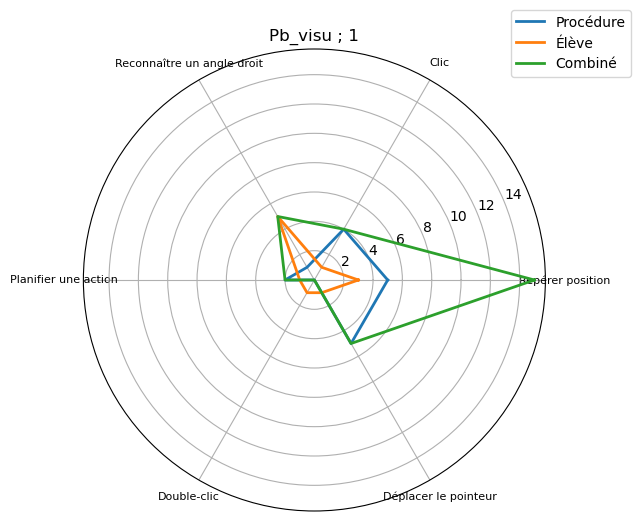

In [191]:
radar_eleve_procedure("el_visu", "proc_test1")

In [202]:
# Un élève, toutes les procédures
def radar_eleve_toutes_procedures(eleve_key: str):
    n = len(dict_procedures)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5), subplot_kw=dict(polar=True))
    if n == 1:
        axes = [axes]

    labels = [get_nom_de(de) for de in next(iter(dict_procedures.values()))["deroulement"]]  # au cas où
    # Mieux : récupérer les labels depuis une procédure de référence
    couts_exemple = calculer_cout_procedure(next(iter(dict_procedures.keys())))
    labels = [get_nom_de(de) for de in couts_exemple.keys()]
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    def close(values): return list(values.values()) + [list(values.values())[0]]

    for ax, proc_key in zip(axes, dict_procedures.keys()):
        couts_proc = calculer_cout_procedure(proc_key)
        couts_combines = calculer_cout_procedure_pour_eleve(proc_key, eleve_key)

        ax.plot(angles, close(couts_proc), color="tab:blue", linewidth=2)
        ax.plot(angles, close(couts_combines), color="tab:orange", linewidth=2)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_title(get_nom_procedure(proc_key), fontsize=10)

    # légende manuelle (une seule fois pour la figure)
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color="tab:blue", lw=2),
        Line2D([0], [0], color="tab:orange", lw=2),
    ]
    fig.legend(custom_lines, ["Procédure brute", f"Pondéré {get_nom_eleve(eleve_key)}"],
               loc="upper right", bbox_to_anchor=(1.05, 1.05))

    fig.suptitle(f"{get_nom_eleve(eleve_key)} ; toutes procédures", fontsize=14)
    plt.show()


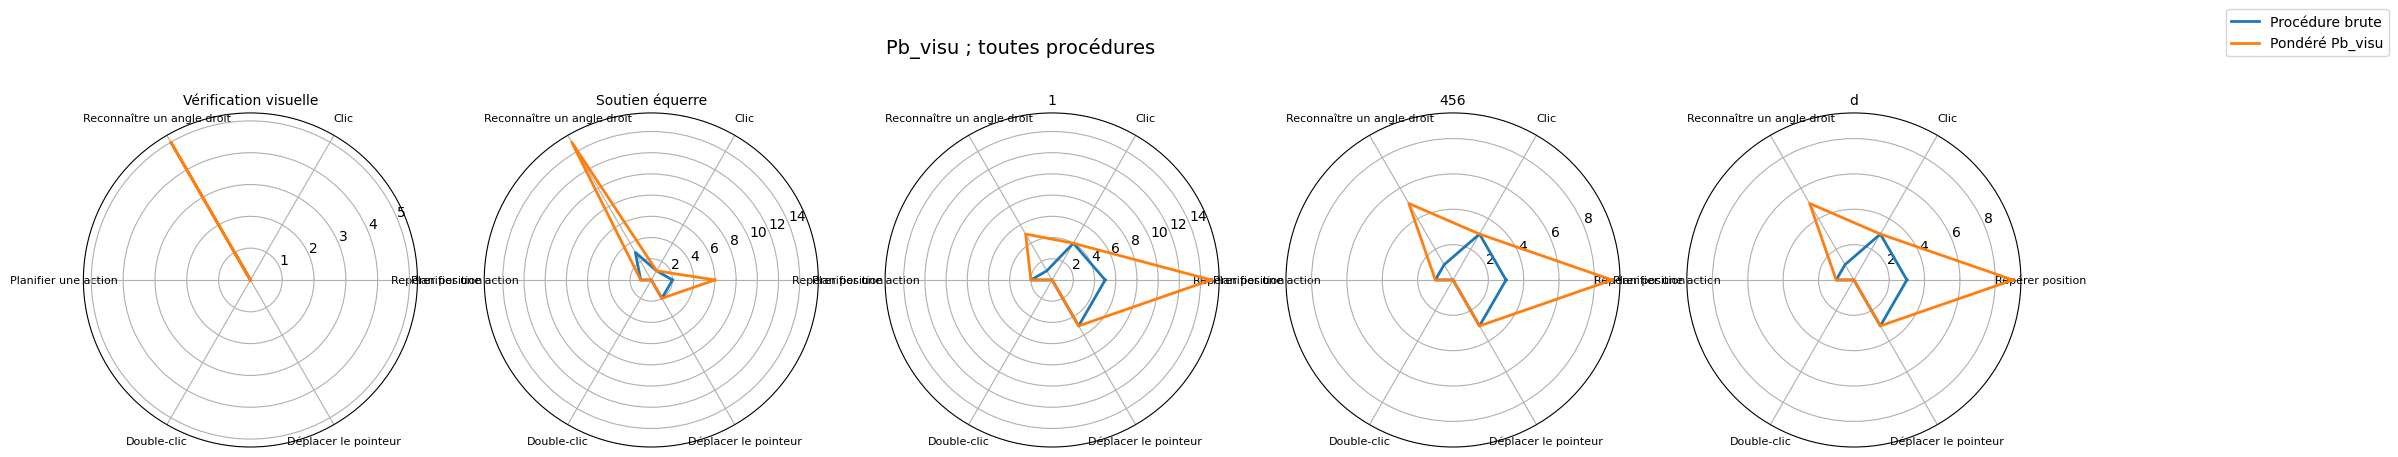

In [203]:
radar_eleve_toutes_procedures("el_visu")

In [204]:
# Une procédure, touts les élèves
def radar_procedure_tous_eleves(proc_key: str):
    n = len(eleves)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5), subplot_kw=dict(polar=True))
    if n == 1:
        axes = [axes]

    couts_proc = calculer_cout_procedure(proc_key)
    labels = [get_nom_de(de) for de in couts_proc.keys()]
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    def close(values): return list(values.values()) + [list(values.values())[0]]

    for ax, (_, row) in zip(axes, eleves.iterrows()):
        eleve_key = row["clef"]
        couts_combines = calculer_cout_procedure_pour_eleve(proc_key, eleve_key)

        ax.plot(angles, close(couts_proc), color="tab:blue", linewidth=2)
        ax.plot(angles, close(couts_combines), color="tab:orange", linewidth=2)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_title(get_nom_eleve(eleve_key), fontsize=10)

    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color="tab:blue", lw=2),
        Line2D([0], [0], color="tab:orange", lw=2),
    ]
    fig.legend(custom_lines, ["Procédure brute", "Pondéré élève"],
               loc="upper right", bbox_to_anchor=(1.05, 1.05))

    fig.suptitle(f"{get_nom_procedure(proc_key)} ; tous les élèves", fontsize=14)
    plt.show()



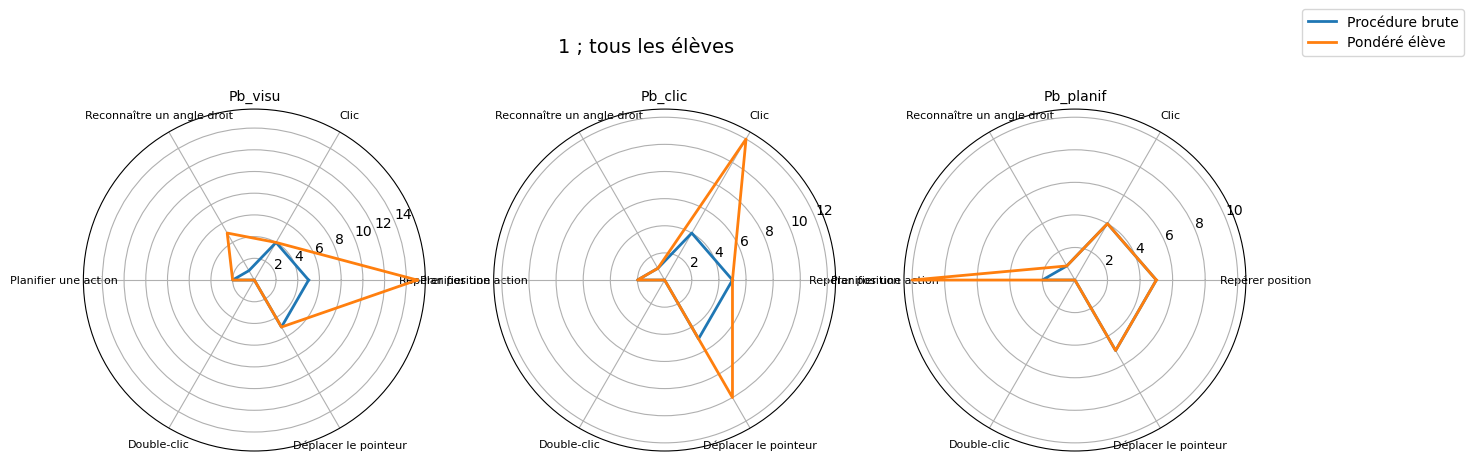

In [205]:
radar_procedure_tous_eleves("proc_test1")

In [206]:
# export de tous les graphes eleve x proc
import os

def sauvegarder_tous_graphes():
    horodatage = datetime.now().strftime("%Y%m%d_%H%M%S")
    dossier = f"graphes_{horodatage}"
    os.makedirs(dossier, exist_ok=True)

    for _, row in eleves.iterrows():
        eleve_key = row["clef"]
        for proc_key in dict_procedures.keys():
            couts_proc = calculer_cout_procedure(proc_key)
            row_eleve = eleves.loc[eleves["clef"] == eleve_key].iloc[0]
            couts_eleve = {de: float(row_eleve.get(de, 0) or 0) for de in couts_proc}
            couts_combines = calculer_cout_procedure_pour_eleve(proc_key, eleve_key)

            labels = [get_nom_de(de) for de in couts_proc.keys()]
            angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
            angles += angles[:1]

            def close(values): return list(values.values()) + [list(values.values())[0]]

            fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
            ax.plot(angles, close(couts_proc), label=f"Procédure {get_nom_procedure(proc_key)}", linewidth=2)
            ax.plot(angles, close(couts_eleve), label=f"Élève {get_nom_eleve(eleve_key)}", linewidth=2)
            ax.plot(angles, close(couts_combines), label="Combiné", linewidth=2)

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(labels, fontsize=8)
            ax.set_title(f"{get_nom_eleve(eleve_key)} ; {get_nom_procedure(proc_key)}")
            ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))

            # Nom de fichier = clef_eleve_clef_procedure.png
            filename = f"{eleve_key}_{proc_key}.png"
            path = os.path.join(dossier, filename)
            plt.savefig(path, bbox_inches="tight")
            plt.close(fig)

    print(f"✅ Graphes sauvegardés dans le dossier : {dossier}")


In [207]:
# export de tous les graphes incluant ceux par élèves et ceux par procédures. Plus gourmand

import os
from matplotlib.lines import Line2D

def sauvegarder_tous_graphes():
    horodatage = datetime.now().strftime("%Y%m%d_%H%M%S")
    dossier = f"graphes_{horodatage}"
    os.makedirs(dossier, exist_ok=True)

    # --- 1. Sauvegarde des radars élémentaires (élève × procédure) ---
    for _, row in eleves.iterrows():
        eleve_key = row["clef"]
        for proc_key in dict_procedures.keys():
            couts_proc = calculer_cout_procedure(proc_key)
            row_eleve = eleves.loc[eleves["clef"] == eleve_key].iloc[0]
            couts_eleve = {de: float(row_eleve.get(de, 0) or 0) for de in couts_proc}
            couts_combines = calculer_cout_procedure_pour_eleve(proc_key, eleve_key)

            labels = [get_nom_de(de) for de in couts_proc.keys()]
            angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
            angles += angles[:1]

            def close(values): return list(values.values()) + [list(values.values())[0]]

            fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
            ax.plot(angles, close(couts_proc), color="tab:blue", linewidth=2)
            ax.plot(angles, close(couts_eleve), color="tab:orange", linewidth=2)
            ax.plot(angles, close(couts_combines), color="tab:green", linewidth=2)

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(labels, fontsize=8)
            ax.set_title(f"{get_nom_eleve(eleve_key)} ; {get_nom_procedure(proc_key)}")

            custom_lines = [
                Line2D([0], [0], color="tab:blue", lw=2),
                Line2D([0], [0], color="tab:orange", lw=2),
                Line2D([0], [0], color="tab:green", lw=2),
            ]
            ax.legend(custom_lines, ["Procédure brute", "Profil élève", "Combiné"],
                      loc="upper right", bbox_to_anchor=(1.2, 1.1))

            filename = f"{eleve_key}_{proc_key}.png"
            plt.savefig(os.path.join(dossier, filename), bbox_inches="tight")
            plt.close(fig)

    # --- 2. Sauvegarde des radars groupés par élève (toutes procédures) ---
    for _, row in eleves.iterrows():
        eleve_key = row["clef"]
        n = len(dict_procedures)
        fig, axes = plt.subplots(1, n, figsize=(5*n, 5), subplot_kw=dict(polar=True))
        if n == 1:
            axes = [axes]

        couts_exemple = calculer_cout_procedure(next(iter(dict_procedures.keys())))
        labels = [get_nom_de(de) for de in couts_exemple.keys()]
        angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
        angles += angles[:1]

        def close(values): return list(values.values()) + [list(values.values())[0]]

        for ax, proc_key in zip(axes, dict_procedures.keys()):
            couts_proc = calculer_cout_procedure(proc_key)
            couts_combines = calculer_cout_procedure_pour_eleve(proc_key, eleve_key)

            ax.plot(angles, close(couts_proc), color="tab:blue", linewidth=2)
            ax.plot(angles, close(couts_combines), color="tab:orange", linewidth=2)

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(labels, fontsize=8)
            ax.set_title(get_nom_procedure(proc_key), fontsize=10)

        custom_lines = [
            Line2D([0], [0], color="tab:blue", lw=2),
            Line2D([0], [0], color="tab:orange", lw=2),
        ]
        fig.legend(custom_lines, ["Procédure brute", f"Pondéré {get_nom_eleve(eleve_key)}"],
                   loc="upper right", bbox_to_anchor=(1.05, 1.05))
        fig.suptitle(f"{get_nom_eleve(eleve_key)} ; toutes procédures", fontsize=14)

        filename = f"{eleve_key}_toutes_procedures.png"
        plt.savefig(os.path.join(dossier, filename), bbox_inches="tight")
        plt.close(fig)

    # --- 3. Sauvegarde des radars groupés par procédure (tous les élèves) ---
    for proc_key in dict_procedures.keys():
        n = len(eleves)
        fig, axes = plt.subplots(1, n, figsize=(5*n, 5), subplot_kw=dict(polar=True))
        if n == 1:
            axes = [axes]

        couts_proc = calculer_cout_procedure(proc_key)
        labels = [get_nom_de(de) for de in couts_proc.keys()]
        angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
        angles += angles[:1]

        def close(values): return list(values.values()) + [list(values.values())[0]]

        for ax, (_, row) in zip(axes, eleves.iterrows()):
            eleve_key = row["clef"]
            couts_combines = calculer_cout_procedure_pour_eleve(proc_key, eleve_key)

            ax.plot(angles, close(couts_proc), color="tab:blue", linewidth=2)
            ax.plot(angles, close(couts_combines), color="tab:orange", linewidth=2)

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(labels, fontsize=8)
            ax.set_title(get_nom_eleve(eleve_key), fontsize=10)

        custom_lines = [
            Line2D([0], [0], color="tab:blue", lw=2),
            Line2D([0], [0], color="tab:orange", lw=2),
        ]
        fig.legend(custom_lines, ["Procédure brute", "Pondéré élève"],
                   loc="upper right", bbox_to_anchor=(1.05, 1.05))
        fig.suptitle(f"{get_nom_procedure(proc_key)} ; tous les élèves", fontsize=14)

        filename = f"tous_eleves_{proc_key}.png"
        plt.savefig(os.path.join(dossier, filename), bbox_inches="tight")
        plt.close(fig)

    print(f"✅ Tous les graphes sauvegardés dans : {dossier}")


✅ Tous les graphes sauvegardés dans : graphes_20250820_175303
